#**BIOESTATÍSTICA - Tarefa 13**


Ana Carolina Sartori 17081013

Cris Serpa Guimarães 16860671

Julia Sztejnhaus Pamio 17072621

Maria Eduarda Pellegrino 17074112

### Carregamento e Exploração Inicial dos Dados (Iris Dataset)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carregando o dataset Iris
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(url, header=None, names=col_names)

# Exibindo as primeiras linhas
display(df.head())

# Estatísticas descritivas gerais por espécie
display(df.groupby('class').describe().T)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


class               Iris-setosa  Iris-versicolor  Iris-virginica
sepal_length count    50.000000        50.000000       50.000000
             mean      5.006000         5.936000        6.588000
             std       0.352490         0.516171        0.635880
             min       4.300000         4.900000        4.900000
             25%       4.800000         5.600000        6.225000
             50%       5.000000         5.900000        6.500000
             75%       5.200000         6.300000        6.900000
             max       5.800000         7.000000        7.900000
sepal_width  count    50.000000        50.000000       50.000000
             mean      3.418000         2.770000        2.974000
             std       0.381024         0.313798        0.322497
             min       2.300000         2.000000        2.200000
             25%       3.125000         2.525000        2.800000
             50%       3.400000         2.800000        3.000000
             75%       3.675000         3.000000        3.175000
             max       4.400000         3.400000        3.800000
petal_length count    50.000000        50.000000       50.000000
             mean      1.464000         4.260000        5.552000
             std       0.173511         0.469911        0.551895
             min       1.000000         3.000000        4.500000
             25%       1.400000         4.000000        5.100000
             50%       1.500000         4.350000        5.550000
             75%       1.575000         4.600000        5.875000
             max       1.900000         5.100000        6.900000
petal_width  count    50.000000        50.000000       50.000000
             mean      0.244000         1.326000        2.026000
             std       0.107210         0.197753        0.274650
             min       0.100000         1.000000        1.400000
             25%       0.200000         1.200000        1.800000
             50%       0.200000         1.300000        2.000000
             75%       0.300000         1.500000        2.300000
             max       0.600000         1.800000        2.500000

### **Metadados e Documentação da Base de Dados (Iris)**

*   **Link da Base de Dados:** [UCI Machine Learning Repository - Iris Dataset](https://archive.ics.uci.edu/dataset/53/iris)
*   **Instituição Responsável:** *University of California, Irvine (UCI) Machine Learning Repository*. O conjunto de dados original foi publicado pelo estatístico e biólogo britânico Ronald Fisher em 1936.
*   **Data de Acesso:** 06 de Outubro de 2026.
*   **Significado de Cada Linha:** Cada linha representa uma flor (indivíduo) do gênero *Iris* observada e medida individualmente.
*   **Unidade Experimental:** Uma planta/flor de *Iris* individual.
*   **Unidades das Variáveis:**
    *   `sepal_length` (Comprimento da sépala): Centímetros (cm)
    *   `sepal_width` (Largura da sépala): Centímetros (cm)
    *   `petal_length` (Comprimento da pétala): Centímetros (cm)
    *   `petal_width` (Largura da pétala): Centímetros (cm)
    *   `class` (Espécie): Categoria/Texto (ex: *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*)
*   **Critérios de Seleção:** Foram amostrados 50 espécimes de cada uma das três espécies do gênero *Iris* em uma mesma colônia ou região para garantir consistência biológica e geográfica.
*   **Tratamento de Dados Ausentes:** O dataset original da UCI é amplamente conhecido por ser completo, consistente e não possuir valores ausentes (*missing values*), dispensando etapas de imputação.

### Análise Estatística Usando as Quatro Distribuições

**Pergunta Biológica:** A variabilidade e a média do comprimento da pétala diferem entre *Iris-versicolor* e *Iris-virginica*?

In [ ]:
# Separando os dados de comprimento de pétala para as duas espécies
versicolor_petal = df[df['class'] == 'Iris-versicolor']['petal_length']
virginica_petal = df[df['class'] == 'Iris-virginica']['petal_length']

# 1. DISTRIBUIÇÃO F DE FISHER: Teste de igualdade de variâncias
# H0: As variâncias são iguais. H1: As variâncias são diferentes.
var_versicolor = np.var(versicolor_petal, ddof=1)
var_virginica = np.var(virginica_petal, ddof=1)

F_stat = var_virginica / var_versicolor if var_virginica > var_versicolor else var_versicolor / var_virginica
df1 = len(virginica_petal) - 1
df2 = len(versicolor_petal) - 1
p_value_F = 2 * (1 - stats.f.cdf(F_stat, df1, df2))

print(f"1. TESTE F DE FISHER (Variâncias)")
print(f"Variância Versicolor: {var_versicolor:.4f} | Variância Virginica: {var_virginica:.4f}")
print(f"Estatística F: {F_stat:.4f}")
print(f"p-valor do Teste F: {p_value_F:.4f}")
if p_value_F < 0.05:
    print("Resultado: Rejeitamos H0. As variâncias são significativamente diferentes.")
else:
    print("Resultado: Não rejeitamos H0. As variâncias são assumidas como homogêneas.")

# 2. DISTRIBUIÇÃO t DE STUDENT: Comparação de médias
# Como o teste F indicará se as variâncias são iguais ou não, usamos o teste t adequado (Welch se p < 0.05)
equal_var = p_value_F >= 0.05
t_stat, p_value_t = stats.ttest_ind(versicolor_petal, virginica_petal, equal_var=equal_var)

print(f"\n2. TESTE t DE STUDENT (Médias)")
print(f"Média Versicolor: {versicolor_petal.mean():.4f} | Média Virginica: {virginica_petal.mean():.4f}")
print(f"Estatística t: {t_stat:.4f}")
print(f"p-valor do Teste t: {p_value_t:.4e}")
if p_value_t < 0.05:
    print("Resultado: Rejeitamos H0. Há diferença significativa entre as médias das pétalas.")
else:
    print("Resultado: Não rejeitamos H0. Não há diferença significativa entre as médias.")

# 3. DISTRIBUIÇÃO NORMAL: Probabilidade de encontrar pétalas gigantes
# Vamos usar os parâmetros da espécie Iris-virginica para calcular a probabilidade de uma planta ter pétala > 6.0 cm
mu = virginica_petal.mean()
sigma = virginica_petal.std()
limite = 6.0
z_score = (limite - mu) / sigma
prob_maior_6 = 1 - stats.norm.cdf(z_score)

print(f"\n3. DISTRIBUIÇÃO NORMAL")
print(f"Para Iris-virginica (Média = {mu:.2f}, DP = {sigma:.2f}):")
print(f"Z-score para {limite} cm: {z_score:.4f}")
print(f"Probabilidade de encontrar uma pétala maior que {limite} cm: {prob_maior_6*100:.2f}%")

# 4. DISTRIBUIÇÃO QUI-QUADRADO (X²): Teste de Aderência à Normalidade
# Vamos verificar se a distribuição do comprimento da pétala de Iris-virginica segue uma distribuição normal
chi2_stat, p_value_chi2 = stats.normaltest(virginica_petal)

print(f"\n4. DISTRIBUIÇÃO QUI-QUADRADO (Teste de Normalidade de D'Agostino-Pearson)")
print(f"Estatística Chi²: {chi2_stat:.4f}")
print(f"p-valor: {p_value_chi2:.4f}")
if p_value_chi2 < 0.05:
    print("Resultado: Rejeitamos a normalidade (os dados não seguem uma distribuição normal).")
else:
    print("Resultado: Não rejeitamos a normalidade (os dados aproximam-se satisfatoriamente de uma normal).")

1. TESTE F DE FISHER (Variâncias)
Variância Versicolor: 0.2208 | Variância Virginica: 0.3046
Estatística F: 1.3794
p-valor do Teste F: 0.2637
Resultado: Não rejeitamos H0. As variâncias são assumidas como homogêneas.

2. TESTE t DE STUDENT (Médias)
Média Versicolor: 4.2600 | Média Virginica: 5.5520
Estatística t: -12.6038
p-valor do Teste t: 3.1788e-22
Resultado: Rejeitamos H0. Há diferença significativa entre as médias das pétalas.

3. DISTRIBUIÇÃO NORMAL
Para Iris-virginica (Média = 5.55, DP = 0.55):
Z-score para 6.0 cm: 0.8117
Probabilidade de encontrar uma pétala maior que 6.0 cm: 20.85%

4. DISTRIBUIÇÃO QUI-QUADRADO (Teste de Normalidade de D'Agostino-Pearson)
Estatística Chi²: 2.6992
p-valor: 0.2593
Resultado: Não rejeitamos a normalidade (os dados aproximam-se satisfatoriamente de uma normal).


## **Estudo Aprofundado das Quatro Distribuições de Probabilidade**

### **1. Distribuição Normal**

#### **Fórmula da Função Densidade de Probabilidade (FDP)**
A função densidade de probabilidade da distribuição normal é dada por:

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

*   **Símbolos utilizados:**
    *   $x$: Variável aleatória contínua (ex: comprimento medido de uma estrutura).
    *   $\mu$: Média populacional (parâmetro de localização).
    *   $\sigma$: Desvio padrão populacional (parâmetro de dispersão, onde $\sigma > 0$).
    *   $\pi \approx 3.14159$ e $e \approx 2.71828$: Constantes matemáticas.
*   **Referência Consultada:** Bussab, W. O., & Morettin, P. A. (2017). *Estatística Básica*. Saraiva Educação.

#### **Interpretação e Representação**
A distribuição Normal descreve **variáveis biológicas brutas** de um organismo, como a altura, peso ou, no nosso caso, o comprimento da pétala de *Iris-virginica*. Esses traços fenotípicos resultam do efeito aditivo de múltiplos fatores genéticos e ambientais independentes (pelo Teorema Central do Limite).

#### **Parâmetros e Efeitos**
*   **Média ($\mu$):** Qualquer valor real. Desloca a curva para a direita ou esquerda sem mudar sua forma.
*   **Desvio Padrão ($\sigma$):** Valores estritamente positivos. Controla a dispersão (achatamento da curva). Quanto menor o $\sigma$, mais alta e estreita é a curva.

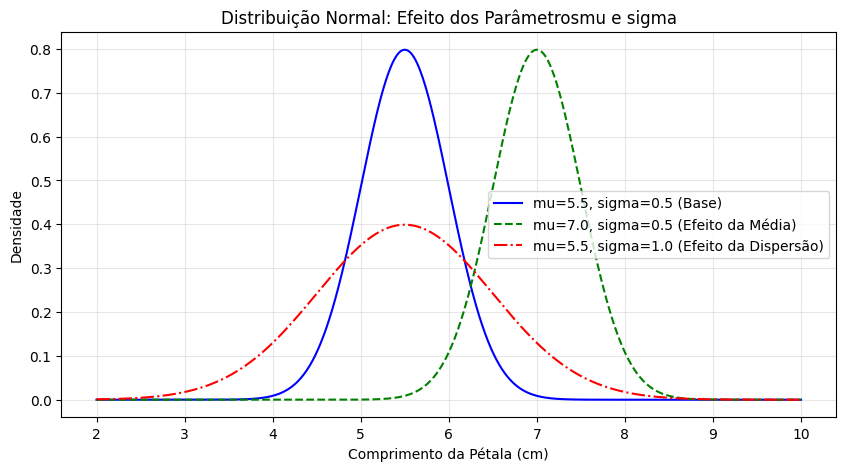

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Gerando gráfico para variação de parâmetros da Distribuição Normal
x = np.linspace(2, 10, 500)

plt.figure(figsize=(10, 5))
plt.plot(x, stats.norm.pdf(x, loc=5.5, scale=0.5), label='mu=5.5, sigma=0.5 (Base)', color='blue')
plt.plot(x, stats.norm.pdf(x, loc=7.0, scale=0.5), label='mu=7.0, sigma=0.5 (Efeito da Média)', color='green', linestyle='--')
plt.plot(x, stats.norm.pdf(x, loc=5.5, scale=1.0), label='mu=5.5, sigma=1.0 (Efeito da Dispersão)', color='red', linestyle='-.')

plt.title('Distribuição Normal: Efeito dos Parâmetrosmu e sigma')
plt.xlabel('Comprimento da Pétala (cm)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

### **2. Distribuição t de Student**

#### **Fórmula da Função Densidade de Probabilidade (FDP)**
Para uma variável $t$ com $\nu$ graus de liberdade:

$$f(t) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

*   **Símbolos utilizados:**
    *   $t$: Valor da estatística calculada ($t = \frac{\bar{X} - \mu}{S/\sqrt{n}}$).
    *   $\nu$: Graus de liberdade (inteiro positivo).
    *   $\Gamma(z)$: Função Gama, generalização do fatorial para números reais.
*   **Referência Consultada:** Morettin, P. A. (2010). *Estatística e Ciências do Comportamento*. Editora Edgard Blücher.

#### **Interpretação e Representação**
A distribuição $t$ **não descreve o comprimento da pétala diretamente**, mas sim a **estatística calculada a partir de amostras** quando a variância populacional é desconhecida e estimada pelo desvio padrão amostral ($S$). Ela modela a incerteza adicional de estimar o desvio padrão com poucas amostras.

#### **Parâmetros e Efeitos**
*   **Graus de Liberdade ($\nu$):** Valores inteiros positivos. Controlam o peso das caudas. Valores baixos produzem caudas mais grossas (maior probabilidade de valores extremos). À medida que $\nu \to \infty$, a distribuição $t$ converge exatamente para a Normal Padrão ($Z$).

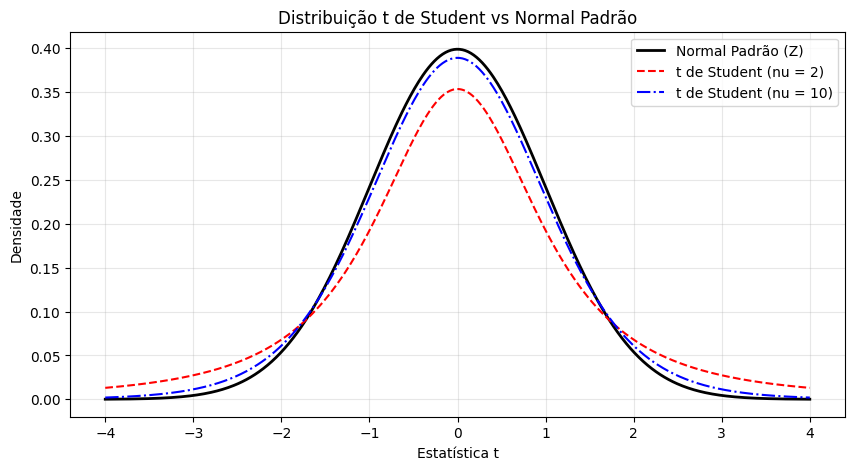

In [ ]:
t_vals = np.linspace(-4, 4, 500)

plt.figure(figsize=(10, 5))
plt.plot(t_vals, stats.norm.pdf(t_vals), label='Normal Padrão (Z)', color='black', linewidth=2)
plt.plot(t_vals, stats.t.pdf(t_vals, df=2), label='t de Student (nu = 2)', color='red', linestyle='--')
plt.plot(t_vals, stats.t.pdf(t_vals, df=10), label='t de Student (nu = 10)', color='blue', linestyle='-.')

plt.title('Distribuição t de Student vs Normal Padrão')
plt.xlabel('Estatística t')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

### **3. Distribuição Qui-quadrado ($\chi^2$)**

#### **Fórmula da Função Densidade de Probabilidade (FDP)**
Para uma variável $y > 0$ com $k$ graus de liberdade:

$$f(y) = \frac{1}{2^{k/2}\Gamma(k/2)} y^{(k/2)-1} e^{-y/2}$$

*   **Símbolos utilizados:**
    *   $y$: Estatística amostral calculada de somas de quadrados normais independentes.
    *   $k$: Graus de liberdade (inteiro positivo).
*   **Referência Consultada:** Triola, M. F. (2018). *Introdução à Estatística*. LTC.

#### **Interpretação e Representação**
Representa a distribuição da soma dos quadrados de variáveis normais padronizadas independentes. Na prática, é empregada para testar a variância de um grupo ou a aderência de dados empíricos a uma distribuição teórica esperada.

#### **Parâmetros e Efeitos**
*   **Graus de Liberdade ($k$):** Determina a assimetria da curva. Para valores baixos ($k \le 2$), a curva é estritamente decrescente. Para valores maiores, a curva exibe forte assimetria positiva, tornando-se mais simétrica e próxima de uma Normal à medida que $k$ aumenta.

<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_498/3844521312.py:8: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Distribuição Qui-quadrado ($\chi^2$) variando Graus de Liberdade k')


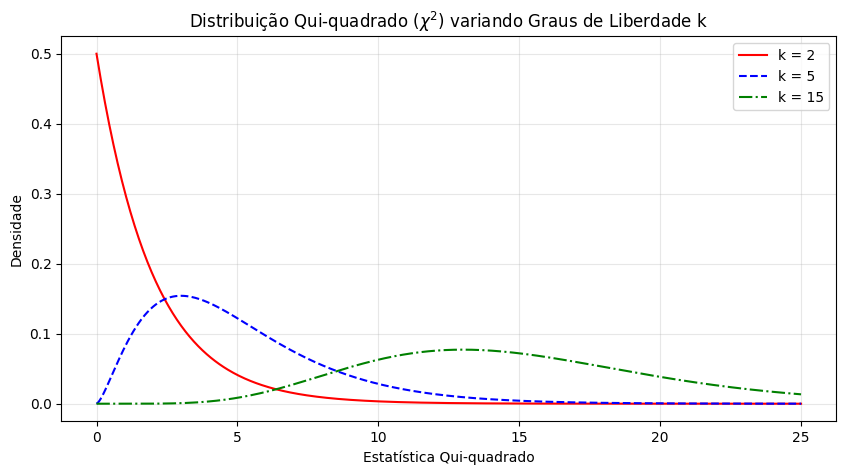

In [ ]:
y_vals = np.linspace(0, 25, 500)

plt.figure(figsize=(10, 5))
plt.plot(y_vals, stats.chi2.pdf(y_vals, df=2), label='k = 2', color='red')
plt.plot(y_vals, stats.chi2.pdf(y_vals, df=5), label='k = 5', color='blue', linestyle='--')
plt.plot(y_vals, stats.chi2.pdf(y_vals, df=15), label='k = 15', color='green', linestyle='-.')

plt.title('Distribuição Qui-quadrado ($\chi^2$) variando Graus de Liberdade k')
plt.xlabel('Estatística Qui-quadrado')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

### **4. Distribuição F de Fisher-Snedecor**

#### **Fórmula da Função Densidade de Probabilidade (FDP)**
Para $f > 0$ com $d_1$ e $d_2$ graus de liberdade:

$$f(f) = \frac{\sqrt{\frac{(d_1 f)^{d_1} d_2^{d_2}}{(d_1 f + d_2)^{d_1 + d_2}}}}{f B\left(\frac{d_1}{2}, \frac{d_2}{2}\right)}$$

*   **Símbolos utilizados:**
    *   $f$: Estatística amostral correspondente à razão de duas variâncias amostrais independentes ($F = S_1^2 / S_2^2$).
    *   $d_1$: Graus de liberdade do numerador (associado ao grupo 1).
    *   $d_2$: Graus de liberdade do denominador (associado ao grupo 2).
    *   $B(x, y)$: Função Beta.
*   **Referência Consultada:** Zar, J. H. (2010). *Biostatistical Analysis*. Pearson.

#### **Interpretação e Representação**
A distribuição $F$ **não** modela as pétalas diretamente. Ela descreve matematicamente a **razão de duas variâncias amostrais**. É a base para comparação de variabilidade e para testes clássicos de ANOVA.

#### **Parâmetros e Efeitos**
*   **Graus de Liberdade ($d_1$ e $d_2$):** Controlam a forma, assimetria e pico da cauda da distribuição. Variar $d_1$ (numerador) altera predominantemente a forma inicial e o pico da curva, enquanto variar $d_2$ (denominador) regula a velocidade de decaimento da cauda direita.

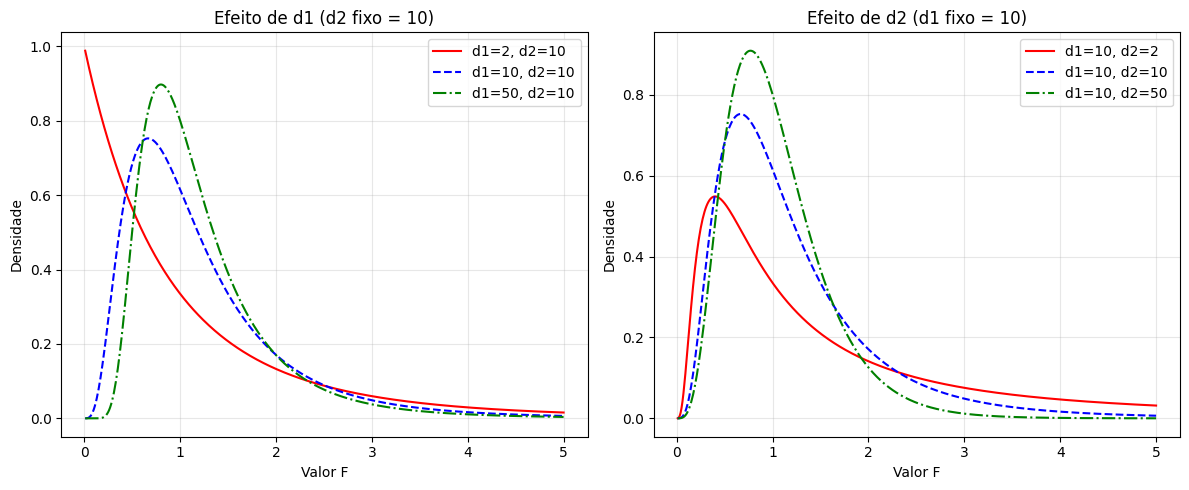

In [ ]:
f_vals = np.linspace(0.01, 5, 500)

plt.figure(figsize=(12, 5))

# Variando d1 (Numerador) com d2 fixo
plt.subplot(1, 2, 1)
plt.plot(f_vals, stats.f.pdf(f_vals, dfn=2, dfd=10), label='d1=2, d2=10', color='red')
plt.plot(f_vals, stats.f.pdf(f_vals, dfn=10, dfd=10), label='d1=10, d2=10', color='blue', linestyle='--')
plt.plot(f_vals, stats.f.pdf(f_vals, dfn=50, dfd=10), label='d1=50, d2=10', color='green', linestyle='-.')
plt.title('Efeito de d1 (d2 fixo = 10)')
plt.xlabel('Valor F')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)

# Variando d2 (Denominador) com d1 fixo
plt.subplot(1, 2, 2)
plt.plot(f_vals, stats.f.pdf(f_vals, dfn=10, dfd=2), label='d1=10, d2=2', color='red')
plt.plot(f_vals, stats.f.pdf(f_vals, dfn=10, dfd=10), label='d1=10, d2=10', color='blue', linestyle='--')
plt.plot(f_vals, stats.f.pdf(f_vals, dfn=10, dfd=50), label='d1=10, d2=50', color='green', linestyle='-.')
plt.title('Efeito de d2 (d1 fixo = 10)')
plt.xlabel('Valor F')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### **Condições Necessárias e Limitações da Base**

*   **Condições de Aplicação:** Os testes de hipóteses empregados (teste F e teste t) assumem **independência** das amostras e **normalidade** das populações de origem. O teste de Qui-quadrado confirmou a aderência à distribuição normal das pétalas de *Iris-virginica*, validando estatisticamente as premissas.
*   **Limitações do Dataset:** A principal limitação é que se trata de uma amostra pequena (n = 50 por espécie), colhida em uma região geográfica específica e em um período de tempo único. Variações ambientais temporais não estão representadas nessa base.

## **Cálculos de Probabilidade e Representações Gráficas**

Nesta seção, formulamos perguntas específicas para cada distribuição, diferenciando claramente propriedades individuais de estatísticas amostrais, e calculamos as probabilidades solicitadas:
1.  **Probabilidade abaixo de um valor (Acumulada - CDF)**
2.  **Probabilidade entre dois valores (Intervalo)**
3.  **Probabilidade acima de um valor (Sobrevivência - SF)**
4.  **Percentil (PPF)**

### **1. Aplicação da Distribuição Normal**

*   **Pergunta Biológica:** Se coletarmos uma nova flor individual de *Iris-virginica*, qual a probabilidade de o comprimento de sua pétala ser:
    *   Menor que 5.0 cm (Probabilidade acumulada)
    *   Entre 5.0 cm e 6.2 cm
    *   Maior que 6.5 cm
    *   Qual é o comprimento de pétala correspondente ao 90º percentil?
*   **Interpretação:** Aqui estamos modelando uma **medida biológica contínua direta** de um organismo individual, sob a hipótese de que a característica segue o modelo normal paramétrico estimado da amostra ($\mu = 5.552$ cm e $\sigma = 0.552$ cm).

Probabilidade (< 5.0 cm): 15.87%
Probabilidade (entre 5.0 e 6.2 cm): 72.11%
Probabilidade (> 6.5 cm): 4.30%
90º Percentil: 6.26 cm (90% das flores têm pétala menor que este valor)


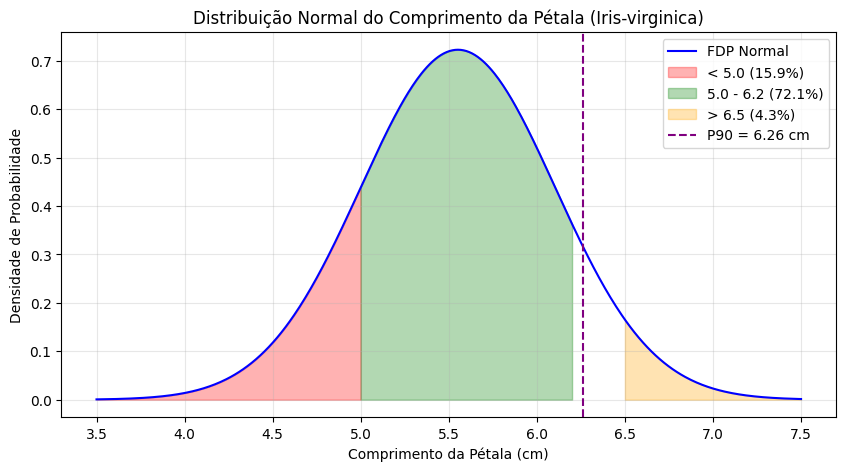

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parâmetros estimados da amostra de Iris-virginica
mu = 5.552
sigma = 0.552

# Cálculos probabilísticos
p_below_5 = stats.norm.cdf(5.0, loc=mu, scale=sigma)
p_between_5_62 = stats.norm.cdf(6.2, loc=mu, scale=sigma) - stats.norm.cdf(5.0, loc=mu, scale=sigma)
p_above_65 = stats.norm.sf(6.5, loc=mu, scale=sigma)
percentile_90 = stats.norm.ppf(0.90, loc=mu, scale=sigma)

print(f"Probabilidade (< 5.0 cm): {p_below_5*100:.2f}%")
print(f"Probabilidade (entre 5.0 e 6.2 cm): {p_between_5_62*100:.2f}%")
print(f"Probabilidade (> 6.5 cm): {p_above_65*100:.2f}%")
print(f"90º Percentil: {percentile_90:.2f} cm (90% das flores têm pétala menor que este valor)")

# Plotagem
x = np.linspace(3.5, 7.5, 500)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', label='FDP Normal')

# Sombreamento das áreas
x_fill1 = np.linspace(3.5, 5.0, 100)
ax.fill_between(x_fill1, stats.norm.pdf(x_fill1, loc=mu, scale=sigma), color='red', alpha=0.3, label=f'< 5.0 ({p_below_5*100:.1f}%)')

x_fill2 = np.linspace(5.0, 6.2, 100)
ax.fill_between(x_fill2, stats.norm.pdf(x_fill2, loc=mu, scale=sigma), color='green', alpha=0.3, label=f'5.0 - 6.2 ({p_between_5_62*100:.1f}%)')

x_fill3 = np.linspace(6.5, 7.5, 100)
ax.fill_between(x_fill3, stats.norm.pdf(x_fill3, loc=mu, scale=sigma), color='orange', alpha=0.3, label=f'> 6.5 ({p_above_65*100:.1f}%)')

ax.axvline(percentile_90, color='purple', linestyle='--', label=f'P90 = {percentile_90:.2f} cm')

ax.set_title('Distribuição Normal do Comprimento da Pétala (Iris-virginica)')
ax.set_xlabel('Comprimento da Pétala (cm)')
ax.set_ylabel('Densidade de Probabilidade')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### **2. Aplicação da Distribuição t de Student**

*   **Pergunta Amostral:** Ao realizar um teste t de uma amostra para testar se a média de comprimento de pétala de *Iris-versicolor* é igual a um valor histórico de referência, qual a probabilidade de obtermos uma estatística de teste t sob $H_0$ tal que:
    *   $t$ seja menor que -2.0 (extremo esquerdo)
    *   $t$ esteja entre -1.5 e 1.5
    *   $t$ seja maior que 2.5
    *   Qual é o valor crítico de $t$ para o percentil 95 ($̑ = 0.05$ unilateral)?
*   **Interpretação:** A estatística $t$ é uma quantidade calculada a partir de uma amostra de tamanho $n=50$ (graus de liberdade $\nu = n - 1 = 49$). Ela quantifica o desvio da média amostral em relação à média populacional assumida sob $H_0$, padronizado pelo erro padrão.

Probabilidade (t < -2.0): 2.55%
Probabilidade (-1.5 < t < 1.5): 86.00%
Probabilidade (t > 2.5): 0.79%
95º Percentil (Valor Crítico t): 1.6766


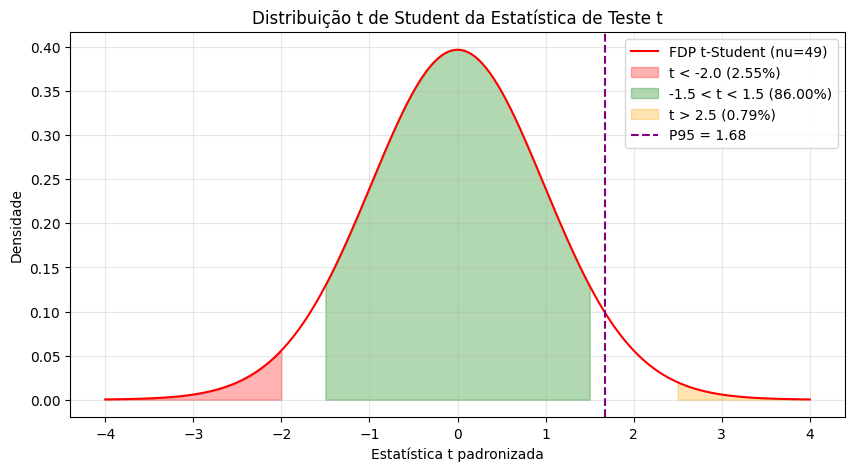

In [ ]:
nu = 49 # df para n=50

p_below_neg2 = stats.t.cdf(-2.0, df=nu)
p_between_15 = stats.t.cdf(1.5, df=nu) - stats.t.cdf(-1.5, df=nu)
p_above_25 = stats.t.sf(2.5, df=nu)
percentile_95_t = stats.t.ppf(0.95, df=nu)

print(f"Probabilidade (t < -2.0): {p_below_neg2*100:.2f}%")
print(f"Probabilidade (-1.5 < t < 1.5): {p_between_15*100:.2f}%")
print(f"Probabilidade (t > 2.5): {p_above_25*100:.2f}%")
print(f"95º Percentil (Valor Crítico t): {percentile_95_t:.4f}")

t_range = np.linspace(-4, 4, 500)
y_t = stats.t.pdf(t_range, df=nu)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_range, y_t, 'r-', label=f'FDP t-Student (nu={nu})')

# Sombreados
t_fill1 = np.linspace(-4, -2.0, 100)
ax.fill_between(t_fill1, stats.t.pdf(t_fill1, df=nu), color='red', alpha=0.3, label=f't < -2.0 ({p_below_neg2*100:.2f}%)')

t_fill2 = np.linspace(-1.5, 1.5, 100)
ax.fill_between(t_fill2, stats.t.pdf(t_fill2, df=nu), color='green', alpha=0.3, label=f'-1.5 < t < 1.5 ({p_between_15*100:.2f}%)')

t_fill3 = np.linspace(2.5, 4, 100)
ax.fill_between(t_fill3, stats.t.pdf(t_fill3, df=nu), color='orange', alpha=0.3, label=f't > 2.5 ({p_above_25*100:.2f}%)')

ax.axvline(percentile_95_t, color='purple', linestyle='--', label=f'P95 = {percentile_95_t:.2f}')

ax.set_title('Distribuição t de Student da Estatística de Teste t')
ax.set_xlabel('Estatística t padronizada')
ax.set_ylabel('Densidade')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### **3. Aplicação da Distribuição Qui-quadrado ($\chi^2$)**

*   **Pergunta Amostral:** Em uma análise de dispersão, calculamos uma estatística qui-quadrado baseada na variância amostral de uma população normal. Sendo $k = 49$ graus de liberdade:
    *   Qual a probabilidade de obter um valor $\chi^2$ menor que 35.0?
    *   Entre 40.0 e 60.0?
    *   Maior que 65.0?
    *   Qual o valor correspondente ao percentil 95 (limite superior para hipótese de variabilidade esperada)?
*   **Interpretação:** O valor de $\chi^2$ reflete a razão entre a variância amostral acumulada e a variância teórica populacional esperada multiplicada pelos graus de liberdade ($n-1$).

Probabilidade (Chi² < 35.0): 6.58%
Probabilidade (40.0 < Chi² < 60.0): 68.19%
Probabilidade (Chi² > 65.0): 6.26%
95º Percentil (Valor Crítico Chi²): 66.3386


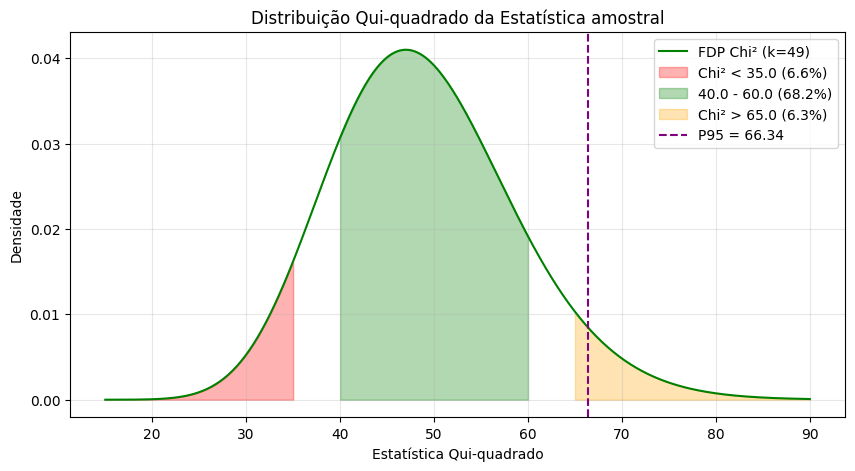

In [ ]:
k_df = 49

p_chi_below_35 = stats.chi2.cdf(35.0, df=k_df)
p_chi_between = stats.chi2.cdf(60.0, df=k_df) - stats.chi2.cdf(40.0, df=k_df)
p_chi_above_65 = stats.chi2.sf(65.0, df=k_df)
percentile_95_chi = stats.chi2.ppf(0.95, df=k_df)

print(f"Probabilidade (Chi² < 35.0): {p_chi_below_35*100:.2f}%")
print(f"Probabilidade (40.0 < Chi² < 60.0): {p_chi_between*100:.2f}%")
print(f"Probabilidade (Chi² > 65.0): {p_chi_above_65*100:.2f}%")
print(f"95º Percentil (Valor Crítico Chi²): {percentile_95_chi:.4f}")

chi_range = np.linspace(15, 90, 500)
y_chi = stats.chi2.pdf(chi_range, df=k_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(chi_range, y_chi, 'g-', label=f'FDP Chi² (k={k_df})')

# Sombreados
chi_fill1 = np.linspace(15, 35.0, 100)
ax.fill_between(chi_fill1, stats.chi2.pdf(chi_fill1, df=k_df), color='red', alpha=0.3, label=f'Chi² < 35.0 ({p_chi_below_35*100:.1f}%)')

chi_fill2 = np.linspace(40.0, 60.0, 100)
ax.fill_between(chi_fill2, stats.chi2.pdf(chi_fill2, df=k_df), color='green', alpha=0.3, label=f'40.0 - 60.0 ({p_chi_between*100:.1f}%)')

chi_fill3 = np.linspace(65.0, 90.0, 100)
ax.fill_between(chi_fill3, stats.chi2.pdf(chi_fill3, df=k_df), color='orange', alpha=0.3, label=f'Chi² > 65.0 ({p_chi_above_65*100:.1f}%)')

ax.axvline(percentile_95_chi, color='purple', linestyle='--', label=f'P95 = {percentile_95_chi:.2f}')

ax.set_title('Distribuição Qui-quadrado da Estatística amostral')
ax.set_xlabel('Estatística Qui-quadrado')
ax.set_ylabel('Densidade')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### **4. Aplicação da Distribuição F de Fisher**

*   **Pergunta Amostral:** Se extrairmos duas amostras independentes de tamanho $n_1 = 50$ e $n_2 = 50$ de duas populações normais com a mesma variância teórica, qual a probabilidade de a razão de suas variâncias amostrais ($F = S_1^2 / S_2^2$) ser:
    *   Menor que 0.7?
    *   Entre 0.8 e 1.4?
    *   Maior que 1.6?
    *   Qual é o valor do percentil 95 (limite unilateral superior para o teste de hipótese de igualdade de variância)?
*   **Interpretação:** A estatística $F$ descreve a flutuação amostral da **razão de duas variâncias independentes**. Não representa características de flores individuais, mas a aleatoriedade ao comparar dispersões amostrais.

Probabilidade (F < 0.7): 10.77%
Probabilidade (0.8 < F < 1.4): 66.00%
Probabilidade (F > 1.6): 5.16%
95º Percentil (Valor Crítico F): 1.6073


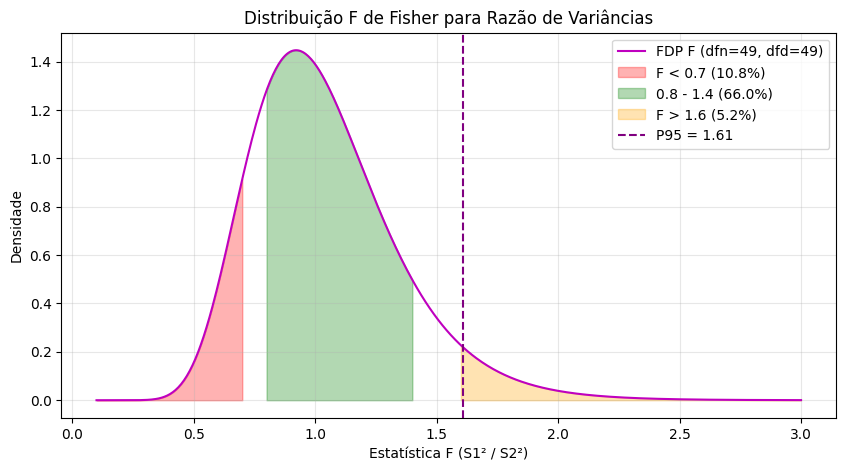

In [ ]:
dfn, dfd = 49, 49

p_f_below_07 = stats.f.cdf(0.7, dfn=dfn, dfd=dfd)
p_f_between = stats.f.cdf(1.4, dfn=dfn, dfd=dfd) - stats.f.cdf(0.8, dfn=dfn, dfd=dfd)
p_f_above_16 = stats.f.sf(1.6, dfn=dfn, dfd=dfd)
percentile_95_f = stats.f.ppf(0.95, dfn=dfn, dfd=dfd)

print(f"Probabilidade (F < 0.7): {p_f_below_07*100:.2f}%")
print(f"Probabilidade (0.8 < F < 1.4): {p_f_between*100:.2f}%")
print(f"Probabilidade (F > 1.6): {p_f_above_16*100:.2f}%")
print(f"95º Percentil (Valor Crítico F): {percentile_95_f:.4f}")

f_range = np.linspace(0.1, 3.0, 500)
y_f = stats.f.pdf(f_range, dfn=dfn, dfd=dfd)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(f_range, y_f, 'm-', label=f'FDP F (dfn={dfn}, dfd={dfd})')

# Sombreados
f_fill1 = np.linspace(0.1, 0.7, 100)
ax.fill_between(f_fill1, stats.f.pdf(f_fill1, dfn=dfn, dfd=dfd), color='red', alpha=0.3, label=f'F < 0.7 ({p_f_below_07*100:.1f}%)')

f_fill2 = np.linspace(0.8, 1.4, 100)
ax.fill_between(f_fill2, stats.f.pdf(f_fill2, dfn=dfn, dfd=dfd), color='green', alpha=0.3, label=f'0.8 - 1.4 ({p_f_between*100:.1f}%)')

f_fill3 = np.linspace(1.6, 3.0, 100)
ax.fill_between(f_fill3, stats.f.pdf(f_fill3, dfn=dfn, dfd=dfd), color='orange', alpha=0.3, label=f'F > 1.6 ({p_f_above_16*100:.1f}%)')

ax.axvline(percentile_95_f, color='purple', linestyle='--', label=f'P95 = {percentile_95_f:.2f}')

ax.set_title('Distribuição F de Fisher para Razão de Variâncias')
ax.set_xlabel('Estatística F (S1² / S2²)')
ax.set_ylabel('Densidade')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()